# Exoplanet Candidate Light Curve Detection
I will be building a system that will help Astrophysicist if the planet is an exoplanet or just a noise which will eventually help them and save their time on investigating non exoplanet.
In this whole project from start to end we will build an end to end ml pipeline include from cleaning, EDA , tuning , encoding , baseline models and also some deep learning task to enhance it and apply the knowledge of it for learning purpose too and give a meaningful project without overdoing things irrationally.
we will be using labelled dataset of keepler time series data (exoTrain.csv.zip,exoTest.csv.zip)

# Data Info

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
exo_train = pd.read_csv("../Raw data/exoTrain.csv.zip")
exo_test = pd.read_csv("../Raw data/exoTest.csv.zip")
print(exo_train, exo_test)

      LABEL   FLUX.1   FLUX.2   FLUX.3   FLUX.4   FLUX.5   FLUX.6  FLUX.7  \
0         2    93.85    83.81    20.10   -26.98   -39.56  -124.71 -135.18   
1         2   -38.88   -33.83   -58.54   -40.09   -79.31   -72.81  -86.55   
2         2   532.64   535.92   513.73   496.92   456.45   466.00  464.50   
3         2   326.52   347.39   302.35   298.13   317.74   312.70  322.33   
4         2 -1107.21 -1112.59 -1118.95 -1095.10 -1057.55 -1034.48 -998.34   
...     ...      ...      ...      ...      ...      ...      ...     ...   
5082      1   -91.91   -92.97   -78.76   -97.33   -68.00   -68.24  -75.48   
5083      1   989.75   891.01   908.53   851.83   755.11   615.78  595.77   
5084      1   273.39   278.00   261.73   236.99   280.73   264.90  252.92   
5085      1     3.82     2.09    -3.29    -2.88     1.66    -0.75    3.85   
5086      1   323.28   306.36   293.16   287.67   249.89   218.30  188.86   

       FLUX.8  FLUX.9  ...  FLUX.3188  FLUX.3189  FLUX.3190  FLUX.3191  \
0

In [3]:
exo_train.head(5), exo_train.tail(5)

(   LABEL   FLUX.1   FLUX.2   FLUX.3   FLUX.4   FLUX.5   FLUX.6  FLUX.7  \
 0      2    93.85    83.81    20.10   -26.98   -39.56  -124.71 -135.18   
 1      2   -38.88   -33.83   -58.54   -40.09   -79.31   -72.81  -86.55   
 2      2   532.64   535.92   513.73   496.92   456.45   466.00  464.50   
 3      2   326.52   347.39   302.35   298.13   317.74   312.70  322.33   
 4      2 -1107.21 -1112.59 -1118.95 -1095.10 -1057.55 -1034.48 -998.34   
 
     FLUX.8  FLUX.9  ...  FLUX.3188  FLUX.3189  FLUX.3190  FLUX.3191  \
 0   -96.27  -79.89  ...     -78.07    -102.15    -102.15      25.13   
 1   -85.33  -83.97  ...      -3.28     -32.21     -32.21     -24.89   
 2   486.39  436.56  ...     -71.69      13.31      13.31     -29.89   
 3   311.31  312.42  ...       5.71      -3.73      -3.73      30.05   
 4 -1022.71 -989.57  ...    -594.37    -401.66    -401.66    -357.24   
 
    FLUX.3192  FLUX.3193  FLUX.3194  FLUX.3195  FLUX.3196  FLUX.3197  
 0      48.57      92.54      39.32      61

- Each FLUX column = brightness at a specific time step
- Each row = A time series signal

In [4]:
exo_test.head(5), exo_test.tail(5)

(   LABEL   FLUX.1   FLUX.2   FLUX.3   FLUX.4   FLUX.5   FLUX.6   FLUX.7  \
 0      2   119.88   100.21    86.46    48.68    46.12    39.39    18.57   
 1      2  5736.59  5699.98  5717.16  5692.73  5663.83  5631.16  5626.39   
 2      2   844.48   817.49   770.07   675.01   605.52   499.45   440.77   
 3      2  -826.00  -827.31  -846.12  -836.03  -745.50  -784.69  -791.22   
 4      2   -39.57   -15.88    -9.16    -6.37   -16.13   -24.05    -0.90   
 
     FLUX.8   FLUX.9  ...  FLUX.3188  FLUX.3189  FLUX.3190  FLUX.3191  \
 0     6.98     6.63  ...      14.52      19.29      14.44      -1.62   
 1  5569.47  5550.44  ...    -581.91    -984.09   -1230.89   -1600.45   
 2   362.95   207.27  ...      17.82     -51.66     -48.29     -59.99   
 3  -746.50  -709.53  ...     122.34      93.03      93.03      68.81   
 4   -45.20    -5.04  ...     -37.87     -61.85     -27.15     -21.18   
 
    FLUX.3192  FLUX.3193  FLUX.3194  FLUX.3195  FLUX.3196  FLUX.3197  
 0      13.33      45.50      3

In [5]:
print(f"Test set shape: {exo_test.shape[0]} rows * {exo_test.shape[1]} columns")

Test set shape: 570 rows * 3198 columns


In [6]:
print("\n Columns")
print(exo_test.columns.to_list())


 Columns
['LABEL', 'FLUX.1', 'FLUX.2', 'FLUX.3', 'FLUX.4', 'FLUX.5', 'FLUX.6', 'FLUX.7', 'FLUX.8', 'FLUX.9', 'FLUX.10', 'FLUX.11', 'FLUX.12', 'FLUX.13', 'FLUX.14', 'FLUX.15', 'FLUX.16', 'FLUX.17', 'FLUX.18', 'FLUX.19', 'FLUX.20', 'FLUX.21', 'FLUX.22', 'FLUX.23', 'FLUX.24', 'FLUX.25', 'FLUX.26', 'FLUX.27', 'FLUX.28', 'FLUX.29', 'FLUX.30', 'FLUX.31', 'FLUX.32', 'FLUX.33', 'FLUX.34', 'FLUX.35', 'FLUX.36', 'FLUX.37', 'FLUX.38', 'FLUX.39', 'FLUX.40', 'FLUX.41', 'FLUX.42', 'FLUX.43', 'FLUX.44', 'FLUX.45', 'FLUX.46', 'FLUX.47', 'FLUX.48', 'FLUX.49', 'FLUX.50', 'FLUX.51', 'FLUX.52', 'FLUX.53', 'FLUX.54', 'FLUX.55', 'FLUX.56', 'FLUX.57', 'FLUX.58', 'FLUX.59', 'FLUX.60', 'FLUX.61', 'FLUX.62', 'FLUX.63', 'FLUX.64', 'FLUX.65', 'FLUX.66', 'FLUX.67', 'FLUX.68', 'FLUX.69', 'FLUX.70', 'FLUX.71', 'FLUX.72', 'FLUX.73', 'FLUX.74', 'FLUX.75', 'FLUX.76', 'FLUX.77', 'FLUX.78', 'FLUX.79', 'FLUX.80', 'FLUX.81', 'FLUX.82', 'FLUX.83', 'FLUX.84', 'FLUX.85', 'FLUX.86', 'FLUX.87', 'FLUX.88', 'FLUX.89', 'FLUX.90',

- We will not touch our test set now to not mess in our pipeline and directly evaluate at the end to check our final real world performance.

In [7]:
# Train set shape
print(f"Train set shape: {exo_train.shape[0]} rows * {exo_train.shape[1]} columns")
# List of all columns
print("\n Columns")
print(exo_train.columns.to_list())

Train set shape: 5087 rows * 3198 columns

 Columns
['LABEL', 'FLUX.1', 'FLUX.2', 'FLUX.3', 'FLUX.4', 'FLUX.5', 'FLUX.6', 'FLUX.7', 'FLUX.8', 'FLUX.9', 'FLUX.10', 'FLUX.11', 'FLUX.12', 'FLUX.13', 'FLUX.14', 'FLUX.15', 'FLUX.16', 'FLUX.17', 'FLUX.18', 'FLUX.19', 'FLUX.20', 'FLUX.21', 'FLUX.22', 'FLUX.23', 'FLUX.24', 'FLUX.25', 'FLUX.26', 'FLUX.27', 'FLUX.28', 'FLUX.29', 'FLUX.30', 'FLUX.31', 'FLUX.32', 'FLUX.33', 'FLUX.34', 'FLUX.35', 'FLUX.36', 'FLUX.37', 'FLUX.38', 'FLUX.39', 'FLUX.40', 'FLUX.41', 'FLUX.42', 'FLUX.43', 'FLUX.44', 'FLUX.45', 'FLUX.46', 'FLUX.47', 'FLUX.48', 'FLUX.49', 'FLUX.50', 'FLUX.51', 'FLUX.52', 'FLUX.53', 'FLUX.54', 'FLUX.55', 'FLUX.56', 'FLUX.57', 'FLUX.58', 'FLUX.59', 'FLUX.60', 'FLUX.61', 'FLUX.62', 'FLUX.63', 'FLUX.64', 'FLUX.65', 'FLUX.66', 'FLUX.67', 'FLUX.68', 'FLUX.69', 'FLUX.70', 'FLUX.71', 'FLUX.72', 'FLUX.73', 'FLUX.74', 'FLUX.75', 'FLUX.76', 'FLUX.77', 'FLUX.78', 'FLUX.79', 'FLUX.80', 'FLUX.81', 'FLUX.82', 'FLUX.83', 'FLUX.84', 'FLUX.85', 'FLUX.86', '

- Each row represents one star

In [8]:
# Data type and null value-counts
print("\n Data info")
exo_train.isnull().sum().value_counts()


 Data info


0    3198
Name: count, dtype: int64

- Here no null value will exist because as its an exoplanet dataset so its mandatory that planet will exist or not.if it doesnt present no other info would be present and on contrast if it exist it will have any kind od info. 

In [9]:
exo_train.describe()

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
count,5087.000000,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,...,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5087.000000,5087.000000,5087.000000,5087.000000
mean,1.007273,1.445054e+02,1.285778e+02,1.471348e+02,1.561512e+02,1.561477e+02,1.469646e+02,1.168380e+02,1.144983e+02,1.228639e+02,...,3.485578e+02,4.956476e+02,6.711211e+02,7.468790e+02,6.937372e+02,6.553031e+02,-494.784966,-544.594264,-440.239100,-300.536399
std,0.084982,2.150669e+04,2.179717e+04,2.191309e+04,2.223366e+04,2.308448e+04,2.410567e+04,2.414109e+04,2.290691e+04,2.102681e+04,...,2.864786e+04,3.551876e+04,4.349963e+04,4.981375e+04,5.087103e+04,5.339979e+04,17844.469520,17722.339334,16273.406292,14459.795577
min,1.000000,-2.278563e+05,-3.154408e+05,-2.840018e+05,-2.340069e+05,-4.231956e+05,-5.975521e+05,-6.724046e+05,-5.790136e+05,-3.973882e+05,...,-3.240480e+05,-3.045540e+05,-2.933140e+05,-2.838420e+05,-3.288214e+05,-5.028894e+05,-775322.000000,-732006.000000,-700992.000000,-643170.000000
25%,1.000000,-4.234000e+01,-3.952000e+01,-3.850500e+01,-3.505000e+01,-3.195500e+01,-3.338000e+01,-2.813000e+01,-2.784000e+01,-2.683500e+01,...,-1.760000e+01,-1.948500e+01,-1.757000e+01,-2.076000e+01,-2.226000e+01,-2.440500e+01,-26.760000,-24.065000,-21.135000,-19.820000
50%,1.000000,-7.100000e-01,-8.900000e-01,-7.400000e-01,-4.000000e-01,-6.100000e-01,-1.030000e+00,-8.700000e-01,-6.600000e-01,-5.600000e-01,...,2.600000e+00,2.680000e+00,3.050000e+00,3.590000e+00,3.230000e+00,3.500000e+00,-0.680000,0.360000,0.900000,1.430000
75%,1.000000,4.825500e+01,4.428500e+01,4.232500e+01,3.976500e+01,3.975000e+01,3.514000e+01,3.406000e+01,3.170000e+01,3.045500e+01,...,2.211000e+01,2.235000e+01,2.639500e+01,2.909000e+01,2.780000e+01,3.085500e+01,18.175000,18.770000,19.465000,20.280000
max,2.000000,1.439240e+06,1.453319e+06,1.468429e+06,1.495750e+06,1.510937e+06,1.508152e+06,1.465743e+06,1.416827e+06,1.342888e+06,...,1.779338e+06,2.379227e+06,2.992070e+06,3.434973e+06,3.481220e+06,3.616292e+06,288607.500000,215972.000000,207590.000000,211302.000000


- 75% or more data is at '1' means its an highly imbalance dataset.which will be dealt in the further steps.   

In [10]:
label_map = {1: "Non-Exoplanet",2: "Exoplanet"}
print(exo_train['LABEL'].map(label_map).value_counts())

LABEL
Non-Exoplanet    5050
Exoplanet          37
Name: count, dtype: int64


In [11]:
exo_train["LABEL"].value_counts(normalize=True)

LABEL
1    0.992727
2    0.007273
Name: proportion, dtype: float64

In [12]:
import seaborn as sns 
import matplotlib.pyplot as plt

# Do Exoplanet Stars behave differently then Non-Exoplanet stars?
Exo_planet = exo_train[exo_train['LABEL'] == 2]
NonExo_planet = exo_train[exo_train['LABEL'] == 1]
# Randomly pick the sample as taking first rows or last rows will create (bias)
planet_sample = Exo_planet.sample(5, random_state= 42)
non_planet_sample = NonExo_planet.sample(5, random_state=42)

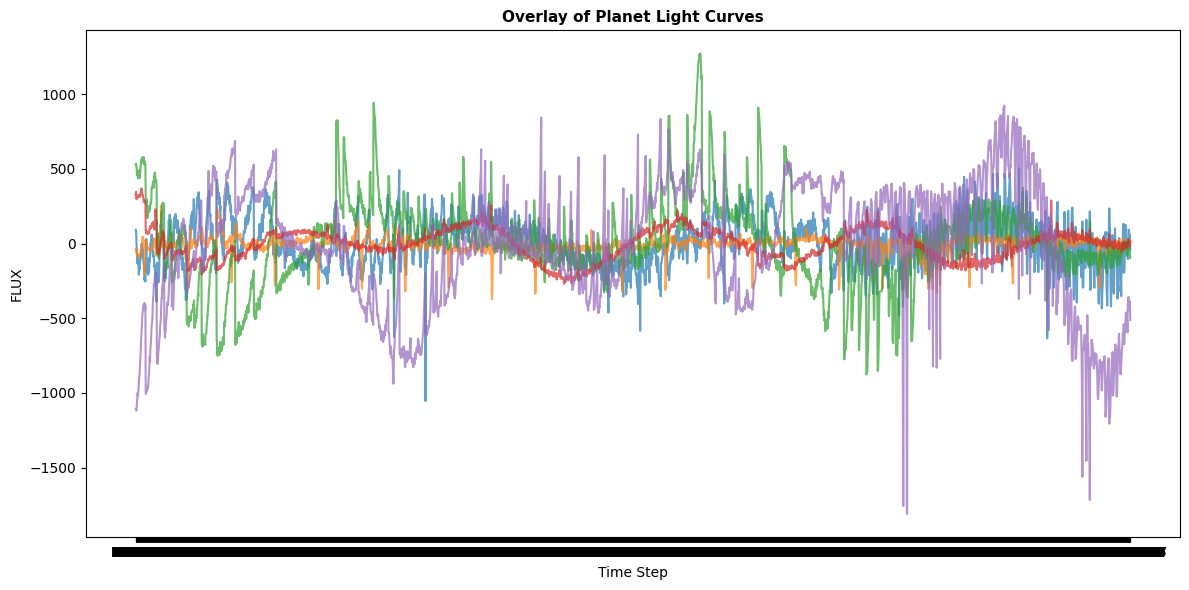

In [13]:
plt.figure(figsize=(12, 6))

for i in range (5):
    plt.plot(Exo_planet.iloc[i, 1:], alpha = 0.7)

plt.title("Overlay of Planet Light Curves",fontsize=11, fontweight='bold')
plt.xlabel("Time Step")
plt.ylabel("FLUX")
plt.tight_layout()
plt.show()

- Each coloured line represents a different star that has a confirmed Exoplanet. They are all planets,just different stars our curve looks messy because every star has its own properties like brightness, noise, orbit timing because its noise we cant say clearly where it takes a dip.

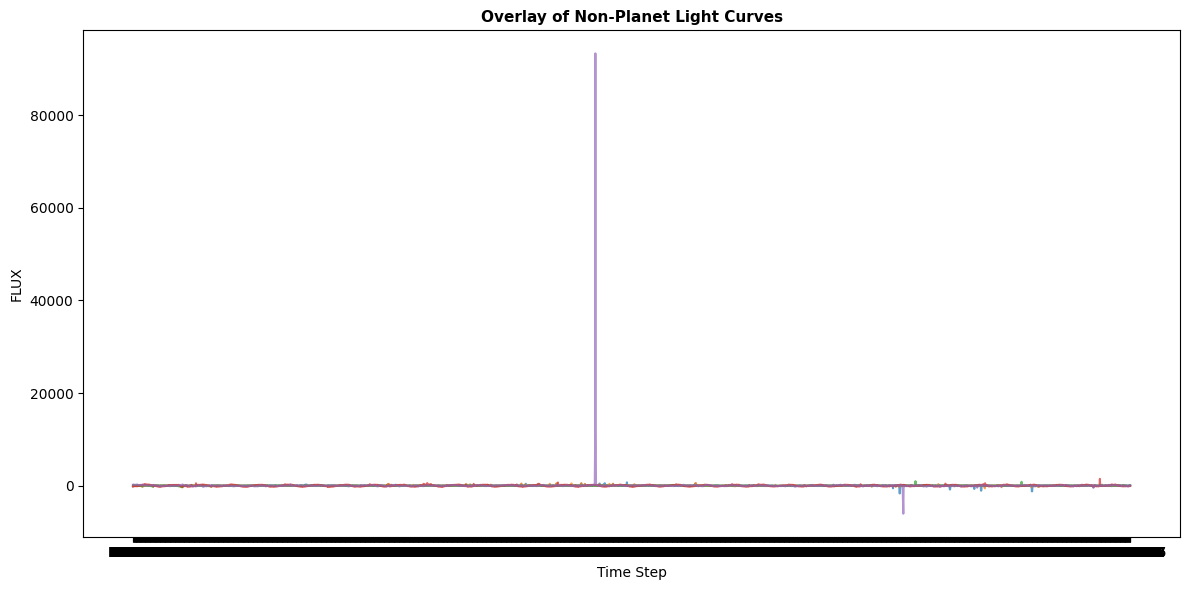

In [14]:
plt.figure(figsize=(12, 6))

for i in range (5):
    plt.plot(NonExo_planet.iloc[i, 1:], alpha = 0.7)

plt.title("Overlay of Non-Planet Light Curves",fontsize=11, fontweight='bold')
plt.xlabel("Time Step")
plt.ylabel("FLUX")
plt.tight_layout()
plt.show()

- Here its clearly seen that a outlier has result in great spike which means instrument noise or an unsual signal and visual distortion. This should be handle before modelling so we will normalization to shrink our value to 0 to 1or -1 to 1.

In [15]:
# Saving our exact same indices that is been used to plot above graphs for furthur comparison after normalization 
sample_indices = Exo_planet.sample(5, random_state= 42).index


# Normalization
- Some stars are bright and some are dim model will learn brightness not planet dips. we will use z-score normalization technique so that every star lives on the same scale  

In [16]:
import numpy as np
# To split the LABEL and FLUX to not change LABEL
x = exo_train.iloc[:, 1:].values #FLUX
y = exo_train.iloc[:, 0].values #LABEl

std = x.std(axis=1, keepdims= True)
std[std == 0] = 1 # we handle it and make it 1 because some stars might have flat signals

# we applied Row-wise Z-score normalisation 
X_norm = (x-x.mean(axis=1, keepdims= True)) / std
print(np.mean(X_norm[0]))
print(np.std(X_norm[0]))


1.8224743300696972e-16
1.0000000000000002


- Our normalzation is been done properly our values are centered around 0 for each star which would be helpful for the model and plotting both 

In [17]:
print(np.isnan(X_norm).sum()) # To check number of NAN values 
print(np.isinf(X_norm).sum()) # To check if their exist infinity

0
0


In [18]:
# We have to take exact same samples that we used before normalization plotting
X_norm_df  = pd.DataFrame(X_norm)
X_norm_df['LABEL'] = exo_train['LABEL'].values
Exo_planet_norm = X_norm_df[X_norm_df['LABEL'] == 2]
planet_sample_norm = Exo_planet_norm.loc[sample_indices]

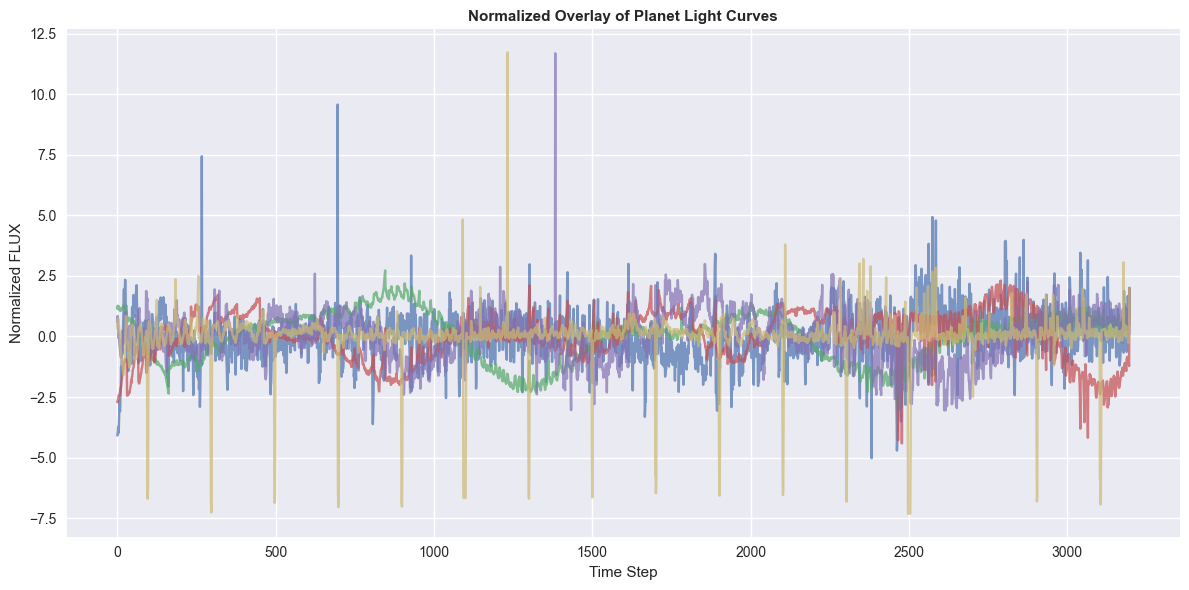

In [19]:
plt.style.use('seaborn-v0_8')
plt.figure(figsize=(12, 6))

for i in range(len(planet_sample_norm)):
    plt.plot(planet_sample_norm.iloc[i, 1:].values, alpha = 0.7)

plt.title("Normalized Overlay of Planet Light Curves",fontsize=11, fontweight='bold')
plt.xlabel("Time Step")
plt.ylabel("Normalized FLUX")
plt.tight_layout()
plt.show()



In [20]:
nonexo_indices = NonExo_planet.sample(5, random_state= 42).index
NonExo_planet_norm = X_norm_df[X_norm_df['LABEL'] == 1]
Nonplanet_sample_norm = NonExo_planet_norm.loc[nonexo_indices]

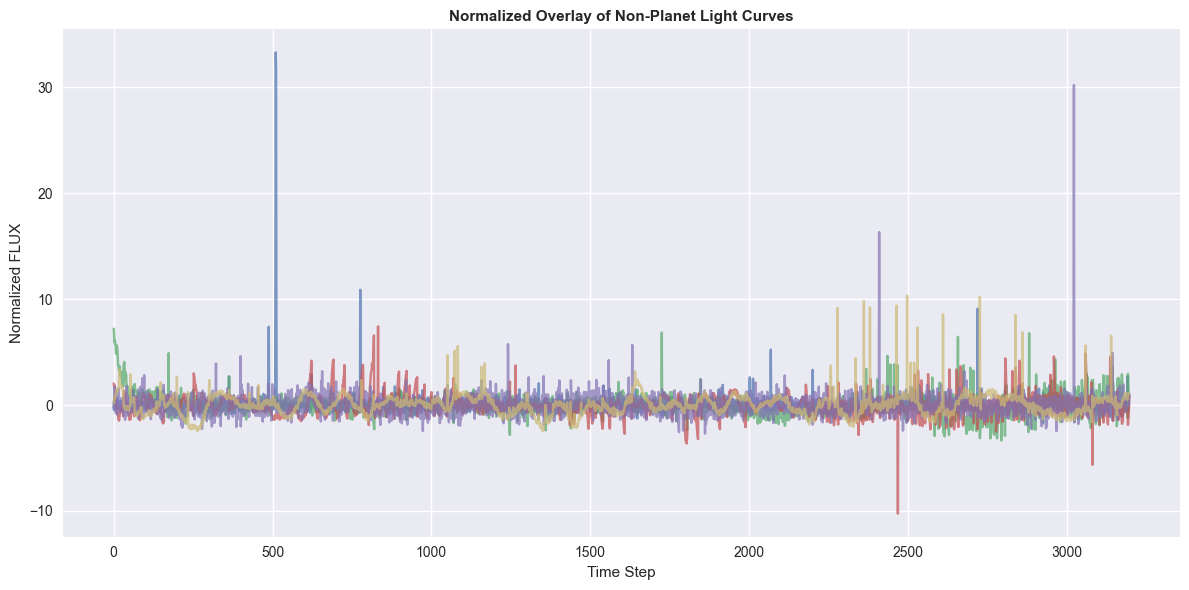

In [21]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')
plt.figure(figsize=(12, 6))

for i in range(len(Nonplanet_sample_norm)):
    plt.plot(Nonplanet_sample_norm.iloc[i, 1:].values, alpha = 0.7)

plt.title("Normalized Overlay of Non-Planet Light Curves",fontsize=11, fontweight='bold')
plt.xlabel("Time Step")
plt.ylabel("Normalized FLUX")
plt.tight_layout()
plt.show()


In [22]:
print(X_norm_df.columns)

Index([      0,       1,       2,       3,       4,       5,       6,       7,
             8,       9,
       ...
          3188,    3189,    3190,    3191,    3192,    3193,    3194,    3195,
          3196, 'LABEL'],
      dtype='object', length=3198)


# Average Light curve per class

In [23]:
# Splitting our data and LABELS 
avg_planet = X_norm_df[X_norm_df['LABEL'] == 2].iloc[:, :-1].values
avg_Nonplanet = X_norm_df[X_norm_df['LABEL'] == 1].iloc[:, :-1].values

print(f"Planets present : {len(avg_planet)}")
print(f"NonPlanet present : {len(avg_Nonplanet)}")

planet_avg = np.mean(avg_planet, axis= 0) # Average of all planet stars
Nonplanet_avg = np.mean(avg_Nonplanet, axis= 0) # Average of all NonPlanet stars

print (f"\noverall averages:")
print (f" Planet Average: {np.mean(planet_avg):.6f}")
print (f" Nonplanet Average: {np.mean(Nonplanet_avg):.6f}")
print (f" Difference: {np.mean(planet_avg) - np.mean(Nonplanet_avg):.6f}")

Planets present : 37
NonPlanet present : 5050

overall averages:
 Planet Average: 0.000000
 Nonplanet Average: 0.000000
 Difference: 0.000000


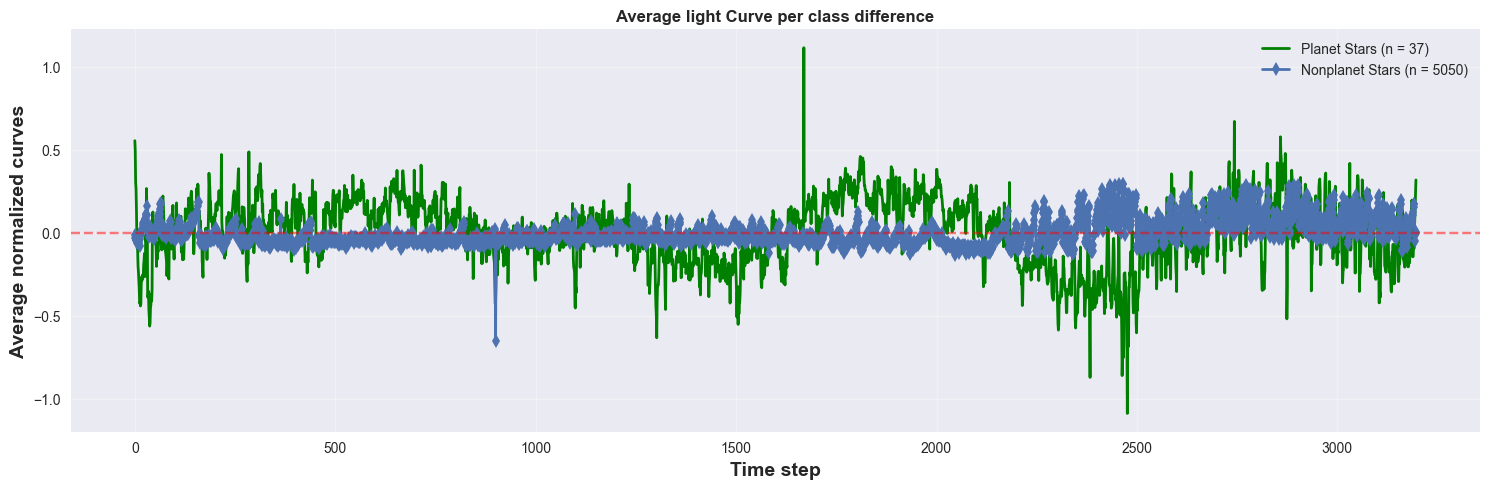

In [24]:
plt.figure(figsize=(15, 5))

plt.plot(planet_avg, 'g-', linewidth = 2, label = f"Planet Stars (n = {len(avg_planet)})")
plt.plot(Nonplanet_avg, 'd-', linewidth = 2, label = f"Nonplanet Stars (n = {len(avg_Nonplanet)})")

plt.title("Average light Curve per class difference", fontweight = 'bold')
plt.xlabel("Time step", fontsize = 14, fontweight = 'bold')
plt.ylabel("Average normalized curves", fontsize = 14, fontweight = 'bold')


plt.axhline( y = 0 , color = 'red', linestyle = '--', alpha = 0.5)
plt.legend()

plt.grid(True, alpha = 0.3)

plt.tight_layout()

plt.show()

- Our Both the classes are centered around 0. It shows that Normalization works perfectly. Brightness scale between stars are removed. So the model will learn shape patterns not the brightness magnitude.

In [25]:
var_planet = X_norm_df[X_norm_df['LABEL'] == 2].iloc[:, :-1].values
var_Nonplanet = X_norm_df[X_norm_df['LABEL'] == 1].iloc[:, :-1].values

planet_var = np.var(var_planet, axis= 0, ddof=1) # Variance of all planet stars
Nonplanet_var = np.var(var_Nonplanet, axis= 0, ddof=1) # Variance of all NonPlanet stars

print (f"\noverall Variance:")
print (f" Planet Variance: {np.var(planet_var):.6f}")
print (f" Nonplanet Variance: {np.var(Nonplanet_var):.6f}")
print (f" Difference: {np.var(planet_var) - np.var(Nonplanet_var):.6f}")


overall Variance:
 Planet Variance: 1.271737
 Nonplanet Variance: 1.086781
 Difference: 0.184956


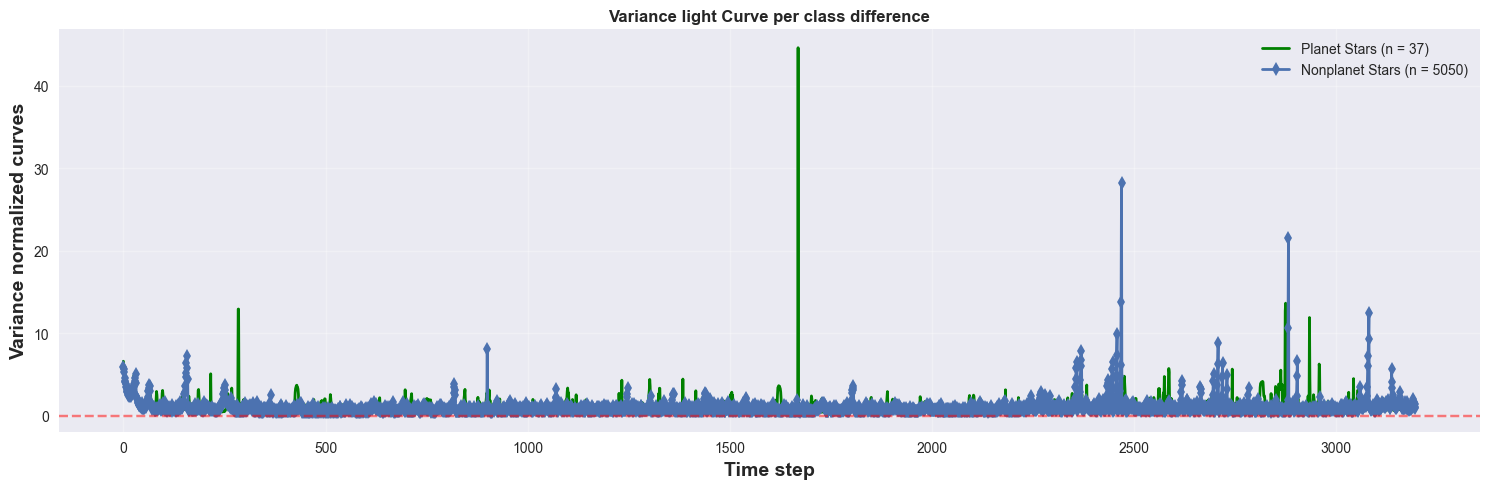

In [26]:
plt.figure(figsize=(15, 5))

plt.plot(planet_var, 'g-', linewidth = 2, label = f"Planet Stars (n = {len(var_planet)})")
plt.plot(Nonplanet_var, 'd-', linewidth = 2, label = f"Nonplanet Stars (n = {len(var_Nonplanet)})")

plt.title("Variance light Curve per class difference", fontweight = 'bold')
plt.xlabel("Time step", fontsize = 14, fontweight = 'bold')
plt.ylabel("Variance normalized curves", fontsize = 14, fontweight = 'bold')


plt.axhline( y = 0 , color = 'red', linestyle = '--', alpha = 0.5)

plt.legend()

plt.grid(True, alpha = 0.3)

plt.tight_layout()

plt.show()

- Now we will see whats the reason behind that certain spikes in out plot


In [27]:

top_var_steps = np.argsort(planet_var)[-7:][::-1]
print(f"Top 7 highest variance time steps: {top_var_steps}")
print(f"Variance values: {planet_var[top_var_steps]}")

Top 7 highest variance time steps: [1669 2875  285  284 2874 2934    0]
Variance values: [44.62421875 13.64000482 12.92592162 12.92592162 12.70463216 11.89979766
  6.5983564 ]


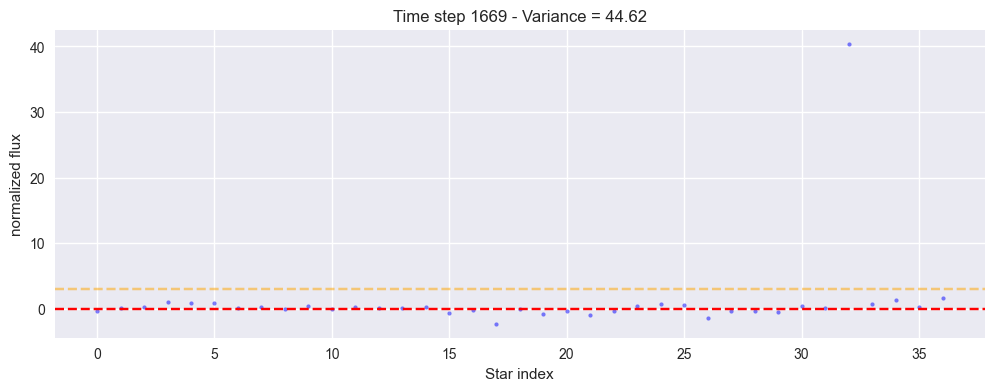

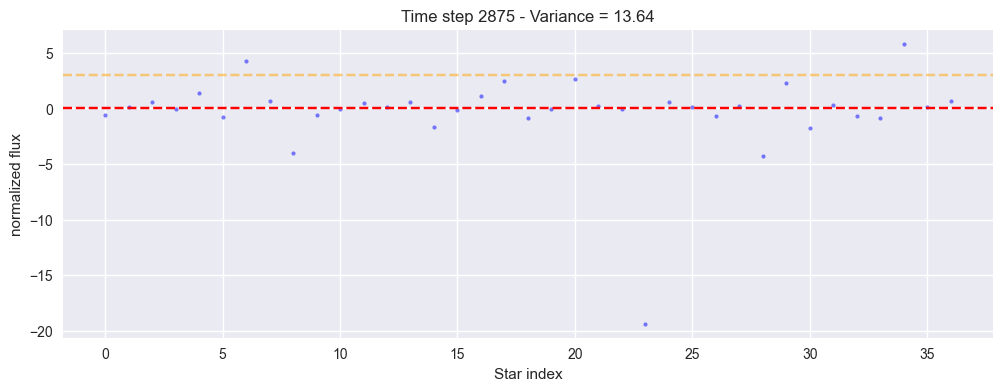

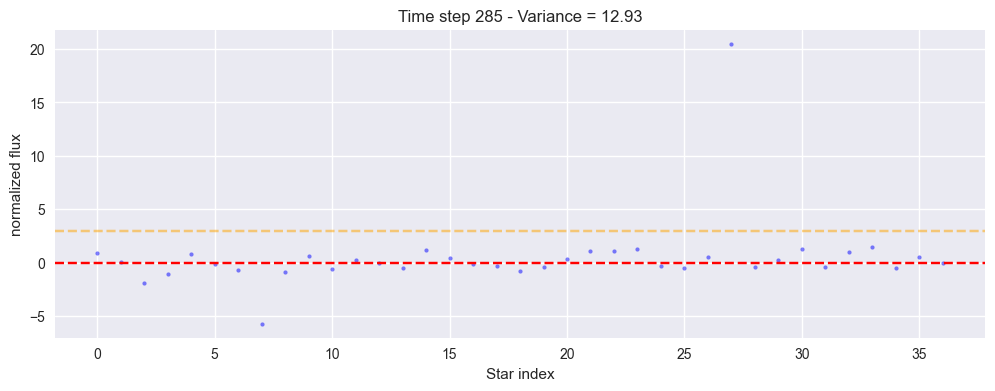

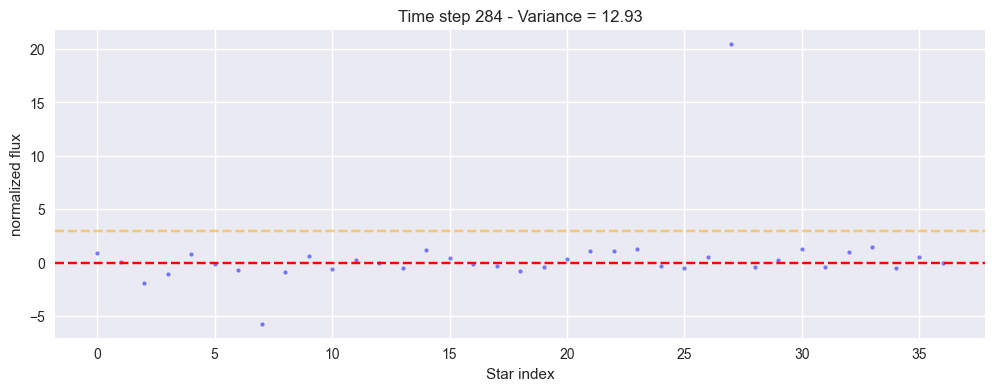

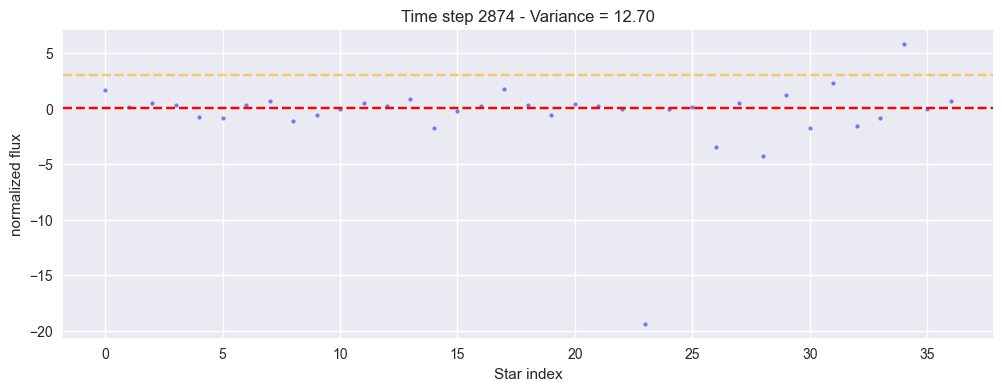

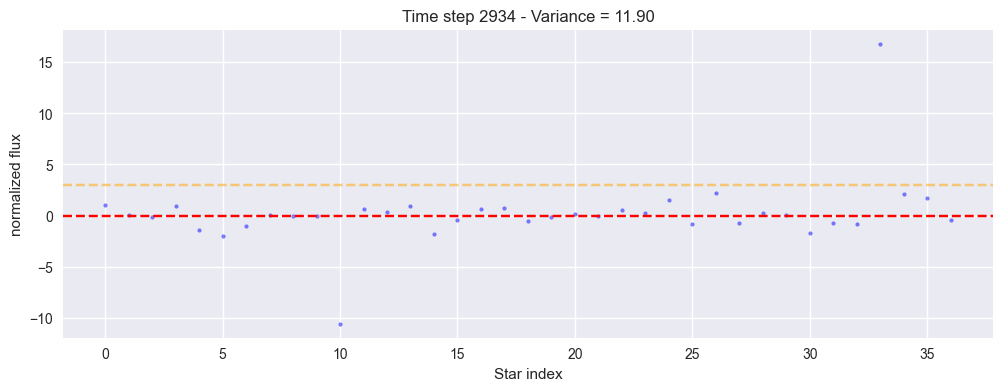

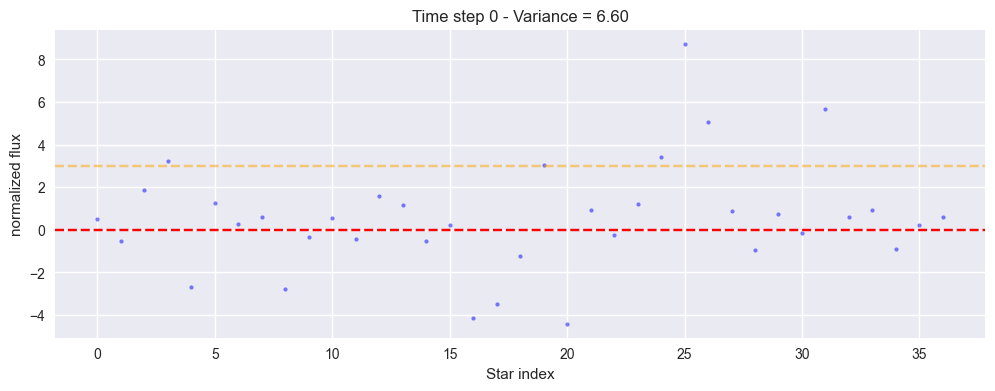

In [28]:
for step in top_var_steps:
    plt.figure(figsize=(12, 4))

    values = var_planet[:, step]

    plt.plot(values, 'bo', markersize = 3, alpha = 0.5)
    plt.axhline(y  = 0, color = 'red', linestyle = '--')
    plt.axhline(y  = 3, color = 'orange', linestyle = '--', alpha = 0.3)
    plt.axhline(y  = 3, color = 'orange', linestyle = '--', alpha = 0.3)


    plt.title(f"Time step {step} - Variance = {planet_var[step]:.2f}")

    plt.xlabel("Star index")
    plt.ylabel("normalized flux")
    plt.show()

- Here we can see clearly on our above plotts that at certain star index 

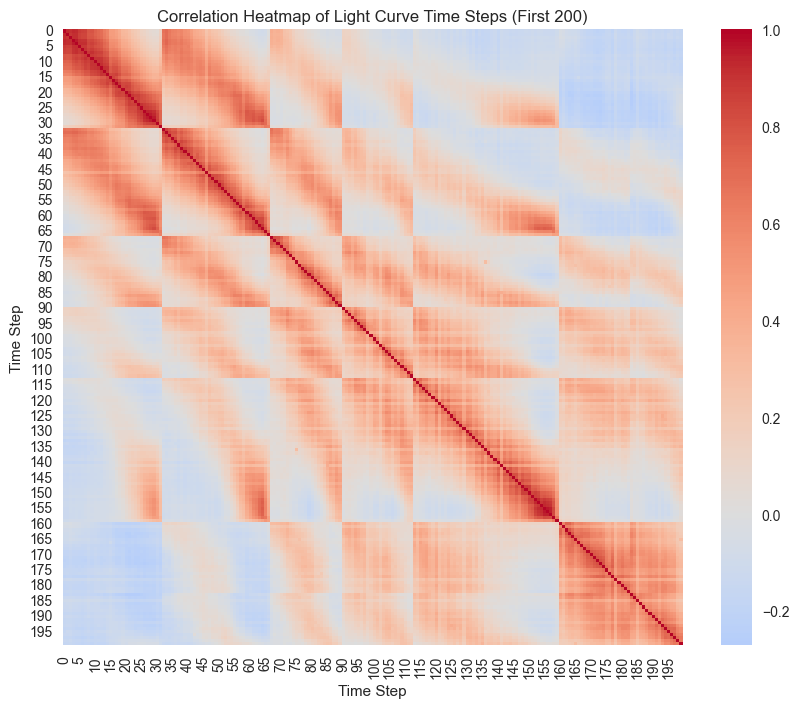

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np

x = X_norm_df.drop(columns=['LABEL'])

subset = x.iloc[:, :200]

corr_matrix = subset.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix, cmap='coolwarm', center= 0)

plt.title("Correlation Heatmap of Light Curve Time Steps (First 200)")

plt.xlabel('Time Step')
plt.ylabel('Time Step')

plt.show()

# Feature Engineering
- We will do Feature engineering for our classical ML models so they can understand the features rather then temporal signals. As their are too many features which would create more overfitting, higher training time, and harder for interpretability. We will also be using the Deep Learning models in this but not touch it with engineered features but we will feed then raw signals as they understand that better.    


In [30]:
X = X_norm_df.drop(columns=['LABEL'])
Y = X_norm_df['LABEL']

print(X.shape)
print(Y.shape)

(5087, 3197)
(5087,)


In [31]:
# Checking if our Target column is correct
print(Y.value_counts)

<bound method IndexOpsMixin.value_counts of 0       2
1       2
2       2
3       2
4       2
       ..
5082    1
5083    1
5084    1
5085    1
5086    1
Name: LABEL, Length: 5087, dtype: int64>


In [32]:
import pandas as pd
import numpy as np

features = pd.DataFrame()

# To compute the basic statistical features rather then raw ones 
features['mean'] = X.mean(axis=1)
features['std'] = X.std(axis=1)
features['min'] = X.min(axis=1)
features['max'] = X.max(axis=1)
features['median'] = X.median(axis=1)
features['range'] = features['max'] - features['min']
# To capture asymmetery and Tail behaviour
features['skew'] = X.skew(axis=1)
features['kurtosis'] = X.kurtosis(axis=1)
features['dip_depth'] = X.min(axis=1)
features['label'] = Y.values
# No of dips occur in it -> More dips = stronger planet signal
threshold = X.mean(axis=1).values.reshape(-1, 1) - X.std(axis=1).values.reshape(-1, 1)
features['dip_count'] = (X.values < threshold).sum (axis=1)
# Sum of Squared brightness values
features['signal_energy'] = (X**2).sum(axis=1) 





In [33]:
features.head()

,mean,std,min,max,median,range,skew,kurtosis,dip_depth,label,dip_count,signal_energy
0,2.478641e-16,1.000156,-6.620421,3.077137,-0.062002,9.697558,0.004394,0.410857,-6.620421,2,495,3197.0
1,1.165786e-16,1.000156,-6.063869,4.334347,0.123962,10.398216,-2.274926,10.064334,-6.063869,2,193,3197.0
2,-5.013541e-16,1.000156,-3.133561,4.493454,-0.029340,7.627015,0.358711,2.205860,-3.133561,2,369,3197.0
3,1.415126e-18,1.000156,-2.555288,3.632312,0.044918,6.187600,-0.004435,-0.027414,-2.555288,2,566,3197.0
4,4.868729e-17,1.000156,-4.408514,2.305719,0.035034,6.714234,-0.527627,0.146406,-4.408514,2,520,3197.0


In [34]:
features.shape

(5087, 12)

- We have succesfully converted our 3197 columns into 10 columns(9 features + 1 label) for better model handling. Now we can smoothly move for model building.

# Model Evaluation

In [35]:
# Seperating the input and target column from our features Dataframe
input = features.drop('label', axis = 1)
target = features['label'].map({1:0, 2:1}) # We will convert our labels to 0 and 1 so our models can understand as its in 1 and 2 

In [36]:
from sklearn.model_selection import train_test_split

x_train, x_val,y_train, y_val = train_test_split(input, target, test_size=0.2, random_state=42, stratify=target)

In [37]:
print(x_train.shape, y_train.shape)

(4069, 11) (4069,)


# Xgboost
- Here we will use scale pos weight to penalize the mistakes. after that  we will do the threshold tuning and find the best threshold value for it and also we will use PR-AUC analysis. 

In [38]:
import numpy as np

pos = np.sum(y_train == 1)
neg = np.sum(y_train == 0)

ratio = neg / pos

print("Scale pos weight:", ratio)


Scale pos weight: 134.63333333333333


In [39]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

xgb_baseline = XGBClassifier(
    n_estimators = 500,
    max_depth = 3,
    learniing_rate = 0.01,
    scale_pos_weight = 134.62,
    random_state = 42, 
    eval_metric = "logloss",
    colsample_bytree = 0.7,
    sub_sample = 0.7,
    reg_alpha = 1,
    reg_lambda = 1,
)

xgb_baseline.fit(x_train, y_train)

y_probs = xgb_baseline.predict_proba(x_val)[:, 1]

y_pred = (y_probs >= 0.5).astype(int)

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1011
           1       0.00      0.00      0.00         7

    accuracy                           0.99      1018
   macro avg       0.50      0.50      0.50      1018
weighted avg       0.99      0.99      0.99      1018



In [40]:
#from xgboost import XGBClassifier
#from sklearn.metrics import classification_report

#xgb_baseline = XGBClassifier(
 #   n_estimators = 400,
  #  max_depth = 5,
   # learniing_rate = 0.05,
    #scale_pos_weight = ratio,
    #random_state = 42, 
    #eval_metric = "logloss"
#)

#xgb_baseline.fit(x_train, y_train)

#y_probs = xgb_baseline.predict_proba(x_val)[:, 1]

#y_pred = (y_probs >= 0.5).astype(int)

#print(classification_report(y_val, y_pred))


In [41]:
from sklearn.metrics import precision_recall_curve, confusion_matrix

precision, recall, thresholds = precision_recall_curve(y_val, y_probs)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best thresholds:", best_threshold)

Best thresholds: 0.0048397128


In [42]:
y_pred = (y_probs >= best_threshold
          ).astype(int)

print(confusion_matrix(y_val, y_pred))
print(classification_report(y_val, y_pred))


[[844 167]
 [  4   3]]
              precision    recall  f1-score   support

           0       1.00      0.83      0.91      1011
           1       0.02      0.43      0.03         7

    accuracy                           0.83      1018
   macro avg       0.51      0.63      0.47      1018
weighted avg       0.99      0.83      0.90      1018



In [43]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_val, y_probs)
print("PR-AUC:", pr_auc)

PR-AUC: 0.01207615777488748


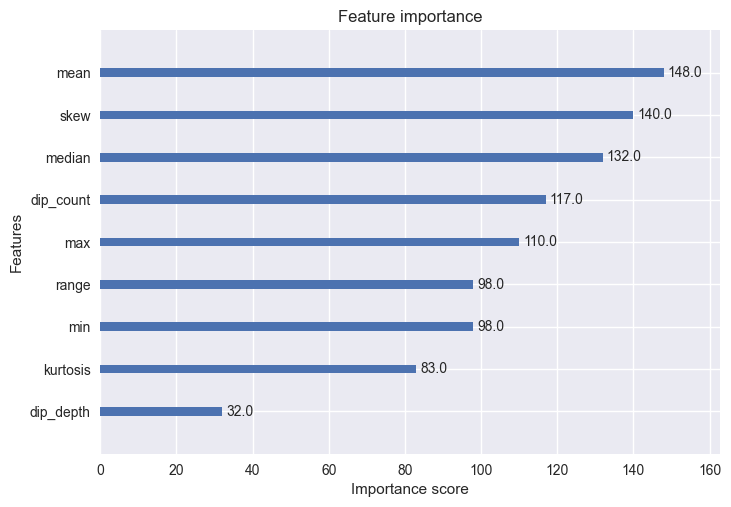

In [44]:
import matplotlib.pyplot as plt
import xgboost as xgb
xgb.plot_importance(xgb_baseline)
plt.show()

In [45]:
selected_features = [
    'mean',
    'skew',
    'median',
    'min',
    'dip_count',
    'max'
]
from xgboost import XGBClassifier

x_train_sel = x_train[selected_features]
x_val_sel = x_val[selected_features]
xgb_reduced = XGBClassifier(
    n_estimators = 400,
    max_depth = 5,
    learniing_rate = 0.05,
    scale_pos_weight = ratio,
    random_state = 42, 
    eval_metric = "logloss"
)

xgb_reduced.fit(x_train_sel, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learniing_rate=0.05,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=None, ...)

In [46]:
y_probs = xgb_reduced.predict_proba(x_val_sel)[:, 1]

In [47]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_val, y_probs)
print("PR-AUC:", pr_auc)

PR-AUC: 0.0138338228357621


In [48]:
y_pred_reduced = (y_probs >= best_threshold).astype(int)

print(confusion_matrix(y_val, y_pred_reduced))
print(classification_report(y_val, y_pred_reduced))

[[962  49]
 [  6   1]]
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1011
           1       0.02      0.14      0.04         7

    accuracy                           0.95      1018
   macro avg       0.51      0.55      0.50      1018
weighted avg       0.99      0.95      0.97      1018



# Hyperparameter tuning
- we will do tuning of xgboost to furthur increase its performance 

In [49]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

params_grid = {
    "max_depth" : [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05,0.06, 0.1],
    "n_estimators" : [200, 300, 400, 500],
    "subsample" : [0.7, 0.8,1.0],
    "colsample_bytree" : [0.7, 0.8,1.0]
}

xgb_tuned = XGBClassifier(
    scale_pos_weight = 134,
    eval_metric = "logloss",
    random_state = 42
)

randomized = RandomizedSearchCV(xgb_tuned, params_grid, n_iter=20, scoring="average_precision", cv=3, verbose=1)

randomized.fit(x_train, y_train)

best_model = randomized.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits


In [50]:
randomized.best_params_

{'subsample': 1.0,
 'n_estimators': 400,
 'max_depth': 4,
 'learning_rate': 0.05,
 'colsample_bytree': 0.7}

In [51]:
y_probs = best_model.predict_proba(x_val)[:, 1]
pr_auc = average_precision_score(y_val, y_probs)
print(pr_auc)

0.010491595023367013


In [52]:
precision, recall, thresholds = precision_recall_curve(y_val, y_probs)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best thresholds:", best_threshold)

y_pred = (y_probs >= best_threshold).astype(int)

print(confusion_matrix(y_val, y_pred))
print(classification_report(y_val, y_pred))

Best thresholds: 0.016967582
[[866 145]
 [  5   2]]
              precision    recall  f1-score   support

           0       0.99      0.86      0.92      1011
           1       0.01      0.29      0.03         7

    accuracy                           0.85      1018
   macro avg       0.50      0.57      0.47      1018
weighted avg       0.99      0.85      0.91      1018



- Tuning doesn't effect our model due to its heavy imbalance so we would prefer above very first metric of xgboost where we used all the features.

In [53]:
from sklearn.metrics import average_precision_score

y_train_probs = xgb_baseline.predict_proba(x_train)[:, 1]

y_val_probs = xgb_baseline.predict_proba(x_val)[:, 1]

train_pr_auc = average_precision_score(y_train, y_train_probs)

val_pr_auc = average_precision_score(y_val, y_val_probs)

print(f"Train PR-AUC:", train_pr_auc)
print(f"Validation PR-AUC:", val_pr_auc)

Train PR-AUC: 0.9999999999999999
Validation PR-AUC: 0.01207615777488748


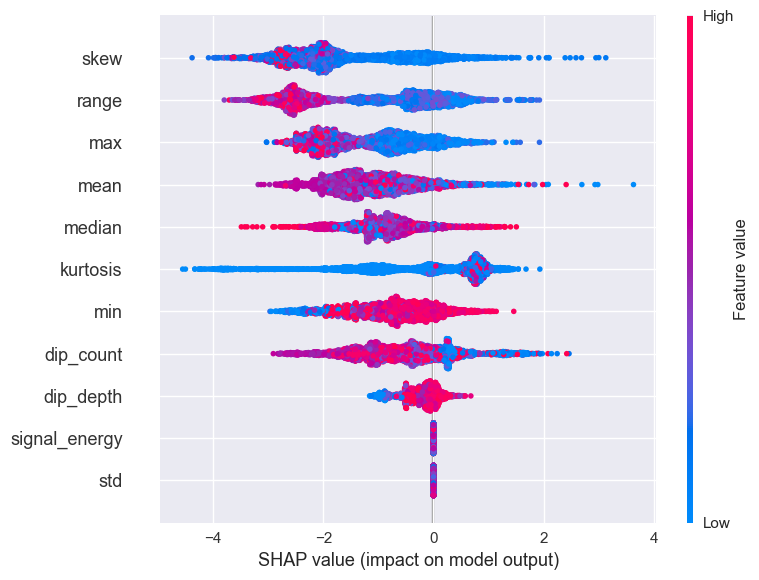

In [54]:
import shap
explainer = shap.Explainer(xgb_baseline)
shap_value = explainer(x_train)

shap.summary_plot(shap_value, x_train)

# Deep Learning
- we will implement deep learning models and use the most powerful models which will help us detect the planets

In [55]:
X_dl = X_norm_df.drop(columns=['LABEL'])
Y_dl = X_norm_df['LABEL']

In [56]:
print(X_dl.shape)
print(Y_dl.shape)

(5087, 3197)
(5087,)


In [57]:
X_dl = X_dl.values
Y_dl = Y_dl.values

In [58]:
from sklearn.model_selection import train_test_split

X_train_dl, X_val_dl, Y_train_dl, Y_val_dl = train_test_split(X_dl, Y_dl, test_size= 0.2, random_state= 42, stratify=Y_dl)

In [59]:
X_train_dl = X_train_dl.reshape(-1, X_train_dl.shape[1], 1 ) 
X_val_dl = X_val_dl.reshape(-1, X_val_dl.shape[1], 1 ) 

In [60]:
X_val_dl.shape

(1018, 3197, 1)

In [61]:
Y_train_dl = Y_train_dl - 1
Y_val_dl = Y_val_dl - 1

In [62]:
print(set(Y_train_dl))
print(set(Y_val_dl))

{np.int64(0), np.int64(1)}
{np.int64(0), np.int64(1)}


In [63]:
import os 
import numpy as np
import random
import tensorflow as tf

seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

In [64]:
pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [65]:
! pip install tensorflow.keras

Defaulting to user installation because normal site-packages is not writeable


In [66]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPool1D, Dropout, Flatten, Dense
from tensorflow.keras import metrics

conv = Sequential([
    Conv1D(32, kernel_size = 5, activation = 'relu',
           input_shape = (X_train_dl.shape[1], 1)), MaxPool1D(2),
           Conv1D(64, 2, activation = 'relu'), MaxPool1D(2),
             Flatten(), 
           Dense( 128, activation= 'relu'), Dropout(0.5),
           Dense(1, activation= 'sigmoid')])

conv.compile(
    optimizer = 'adamW',
    loss = 'binary_crossentropy',
    metrics = ['precision', 'recall']
    )

# To handle our imbalance
from sklearn.utils import  class_weight

weights = class_weight.compute_class_weight('balanced',
classes = np.unique(y_train),
y = y_train )

class_weights = {0 : 1, 1 : 8}

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience= 3, restore_best_weights= True)
conv.fit(X_train_dl, Y_train_dl, validation_data=(X_val_dl, Y_val_dl), callbacks=[early_stop])

history = conv.fit(
    X_train_dl, Y_train_dl,
    validation_data = (X_val_dl, Y_val_dl),
    epochs = 15,
    batch_size = 32,
    class_weight = class_weights,
    shuffle = False,
    callbacks = [early_stop]
)

128/128 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - loss: 0.1670 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_loss: 0.0412 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 1/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - loss: 0.1439 - precision: 0.5000 - recall: 0.0333 - val_loss: 0.0392 - val_precision: 1.0000 - val_recall: 0.1429
Epoch 2/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - loss: 0.0696 - precision: 0.9333 - recall: 0.4667 - val_loss: 0.0308 - val_precision: 1.0000 - val_recall: 0.2857
Epoch 3/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - loss: 0.0460 - precision: 1.0000 - recall: 0.6333 - val_loss: 0.0289 - val_precision: 1.0000 - val_recall: 0.2857
Epoch 4/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - loss: 0.0517 - precision: 0.9286 - recall: 0.4333 - val_loss: 0.0244 - val_precision: 0.7500 - val_recall: 0.4286
Epoch 5/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - loss: 0.0411 - precision: 1.0000 - recall: 0.5333 - val_loss: 0.0246 - val_precision: 0.5000 -

In [67]:
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(Y_train_dl),
    y=Y_train_dl
)

# Keras expects a dictionary mapping class indices to their weights
class_weights_dict = {i: weight for i, weight in enumerate(class_weights)}

print("Calculated Class Weights:")
print(f"Weight for Class 0 (Non-Exoplanet): {class_weights_dict[0]:.2f}")
print(f"Weight for Class 1 (Exoplanet): {class_weights_dict[1]:.2f}")

Calculated Class Weights:
Weight for Class 0 (Non-Exoplanet): 0.50
Weight for Class 1 (Exoplanet): 67.82


In [68]:
y_probs = conv.predict(X_val_dl)
print(f"MAX:", y_probs.max())
print(f"Min:", y_probs.min())

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
MAX: 0.9820833
Min: 3.9258972e-24


In [69]:
precision, recall, thresholds = precision_recall_curve(Y_val_dl, y_probs)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best thresholds:", best_threshold)

y_pred = (y_probs >= best_threshold).astype(int)

print(confusion_matrix(Y_val_dl, y_pred))
print(classification_report(Y_val_dl, y_pred))

Best thresholds: 0.7727937
[[1010    1]
 [   3    4]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1011
           1       0.80      0.57      0.67         7

    accuracy                           1.00      1018
   macro avg       0.90      0.79      0.83      1018
weighted avg       1.00      1.00      1.00      1018



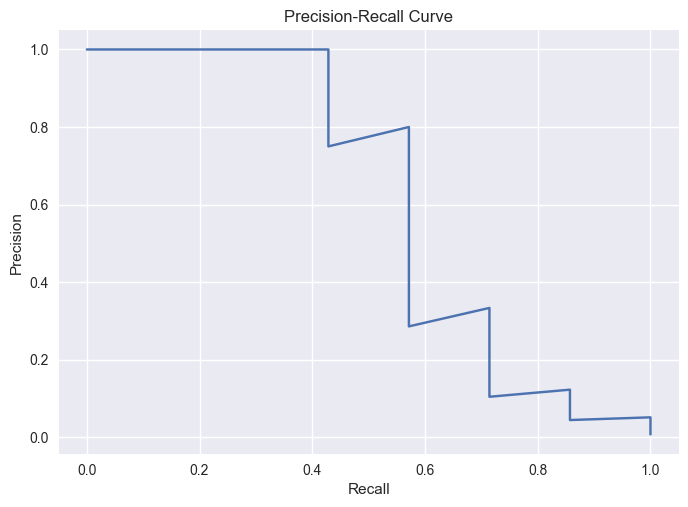

In [70]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(Y_val_dl, y_probs) 
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

In [71]:
from sklearn.metrics import average_precision_score

Y_train_proba= conv.predict(X_train_dl)

Y_val_proba = conv.predict(X_val_dl)

train_PR_AUC = average_precision_score(Y_train_dl, Y_train_proba)

val_PR_AUC = average_precision_score(Y_val_dl, Y_val_proba)

print(f"Train PR-AUC:", train_PR_AUC)
print(f"Validation PR-AUC:", val_PR_AUC)

128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Train PR-AUC: 0.9999999999999999
Validation PR-AUC: 0.6152681719194455


In [72]:
X_train_dl.shape

(4069, 3197, 1)

In [73]:
from sklearn.metrics import average_precision_score

pr_auc_conv = average_precision_score(Y_val_dl, y_probs)
print("PR-AUC:", pr_auc_conv)

PR-AUC: 0.6152681719194455


In [74]:
y_probs_check = conv.predict(X_val_dl)
pr_auc_conv = average_precision_score(Y_val_dl, y_probs_check)
print("PR-AUC:", pr_auc_conv)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
PR-AUC: 0.6152681719194455


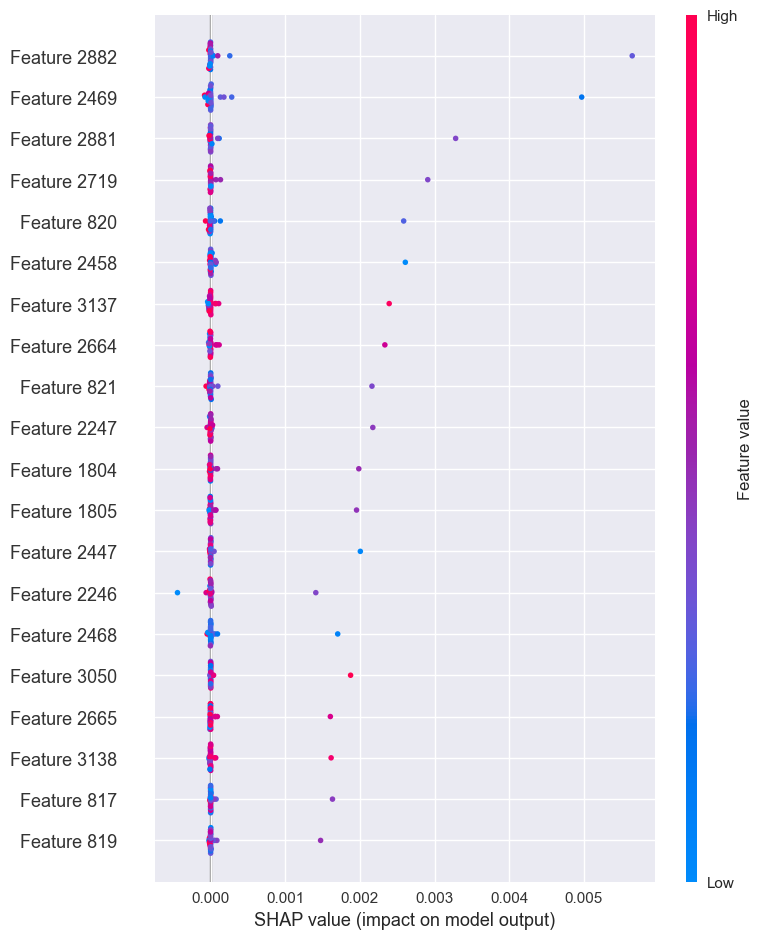

In [75]:
import shap

background = np.random.choice(X_train_dl.shape[0], 85, replace= False)
background_data = X_train_dl[background]

explainer_conv = shap.DeepExplainer(conv, background_data)
X_samples = X_val_dl[:30]
shap_value_conv = explainer_conv.shap_values(X_samples)

if isinstance (shap_value_conv, list):
    shap_planet = shap_value_conv[1]
else:
    shap_planet = shap_value_conv

shap_2D = shap_planet.reshape(shap_planet.shape[0], -1)
X_2d = X_samples.reshape(X_samples.shape[0], -1) 

shap.summary_plot(shap_2D, X_2d )

# EVALUATION ON TEST SET

In [76]:
# SEPERATING THE FIRST COLUMN(Label)
X_test = exo_test.iloc[:, 1:].values # Take all the rows and column except label one 
# label COLUMN ON Y_test
Y_test = exo_test.iloc[:, 0].values # Take all rows and only column 0 

In [77]:
Y_test.shape

(570,)

In [78]:
X_test.shape

(570, 3197)

In [79]:
Y_test_labels = (Y_test == 2).astype(int)

In [80]:
Y_test_labels.shape

(570,)

In [81]:
import numpy as np
import pandas as pd

std_test = X_test.std(axis=1, keepdims= True)
std_test[std_test == 0] = 1 # we handle it and make it 1 because some stars might have flat signals

# we applied Row-wise Z-score normalisation 
X_norm_test = (X_test-X_test.mean(axis=1, keepdims= True)) / std_test
print(np.mean(X_norm_test[0]))
print(np.std(X_norm_test[0]))


-3.556047473306726e-17
0.9999999999999989


In [82]:
x_test_cnn = X_norm_test.reshape(X_norm_test.shape[0], X_norm_test.shape[1], 1)
y_pred_test = conv.predict(x_test_cnn)
y_pred_results = (y_pred_test > 0.6).astype(int) 
print(confusion_matrix(Y_test_labels, y_pred_results))
print(classification_report(Y_test_labels, y_pred_results))


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
[[564   1]
 [  2   3]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       565
           1       0.75      0.60      0.67         5

    accuracy                           0.99       570
   macro avg       0.87      0.80      0.83       570
weighted avg       0.99      0.99      0.99       570



# Hyperparameter Tuning (CNN 1D)
- We will do tuning of CNN 1D and change class weights with focal loss to make model focus on rare planets and improve the recall WITHOUT killing precision and also add early stopping o get our best performance and change our metrics to PR-AUC as its best for imbalance data.

In [83]:
import tensorflow as tf
def focal_loss(alpha = 0.5 , gamma = 2):
    def loss (Y_true, y_pred):
        Y_true = tf.cast(Y_true, tf.float32)

        bce = tf.keras.losses.binary_crossentropy(Y_true, y_pred)
        pt = tf.exp(-bce)
        focal = alpha * (1- pt) ** gamma * bce
        return focal
    return loss

In [84]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPool1D, Dropout, Flatten, Dense, BatchNormalization
from tensorflow.keras import metrics

conv_tuned = Sequential([
    Conv1D(32, kernel_size = 5, activation = 'relu',
           input_shape = (X_train_dl.shape[1], 1)), BatchNormalization(), MaxPool1D(2),
           Conv1D(32, kernel_size=5, activation='relu'), BatchNormalization(), MaxPool1D(2),
           Conv1D(64, 2, activation = 'relu'),BatchNormalization(), MaxPool1D(2),Flatten(),
           Dense( 128, activation= 'relu'), Dropout(0.5),
           Dense(1, activation= 'sigmoid')])

conv_tuned.compile(
    optimizer = 'adamW',
    loss = focal_loss(alpha=0.5, gamma= 2.0),
    metrics = ['precision', 'recall']
    )
history = conv_tuned.fit(
    X_train_dl, Y_train_dl,
    validation_data = (X_val_dl, Y_val_dl),
    epochs = 15,
    batch_size = 32,
    shuffle = False,
)

Epoch 1/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 13s 75ms/step - loss: 0.1265 - precision: 0.0333 - recall: 0.0667 - val_loss: 0.0288 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 9s 72ms/step - loss: 0.0410 - precision: 0.3030 - recall: 0.3333 - val_loss: 0.0171 - val_precision: 0.5000 - val_recall: 0.1429
Epoch 3/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - loss: 0.0109 - precision: 0.7097 - recall: 0.7333 - val_loss: 0.0227 - val_precision: 1.0000 - val_recall: 0.1429
Epoch 4/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 9s 72ms/step - loss: 0.0189 - precision: 0.5517 - recall: 0.5333 - val_loss: 0.0226 - val_precision: 1.0000 - val_recall: 0.1429
Epoch 5/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 9s 72ms/step - loss: 0.0050 - precision: 0.6667 - recall: 0.6000 - val_loss: 0.0241 - val_precision: 0.3333 - val_recall: 0.1429
Epoch 6/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 9s 72ms/step - loss: 0.0087 - precision: 0.7419 - recall: 0.7667 - val_loss: 0.0303 - val_precision: 0.500

In [85]:
y_probs_tuned = conv_tuned.predict(X_val_dl)
print(f"MAX:", y_probs.max())
print(f"Min:", y_probs.min())

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
MAX: 0.9820833
Min: 3.9258972e-24


In [86]:
precision, recall, thresholds_tuned = precision_recall_curve(Y_val_dl, y_probs_tuned)

f1_scores_tuned = 2 * (precision * recall) / (precision + recall + 1e-8)

best_idx = np.argmax(f1_scores_tuned)
best_threshold_tuned = thresholds_tuned[best_idx]

print("Best thresholds:", best_threshold_tuned)

y_pred_tuned = (y_probs_tuned >= best_threshold_tuned).astype(int)

print(confusion_matrix(Y_val_dl, y_pred_tuned))
print(classification_report(Y_val_dl, y_pred_tuned))

Best thresholds: 0.8686358
[[1009    2]
 [   4    3]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1011
           1       0.60      0.43      0.50         7

    accuracy                           0.99      1018
   macro avg       0.80      0.71      0.75      1018
weighted avg       0.99      0.99      0.99      1018



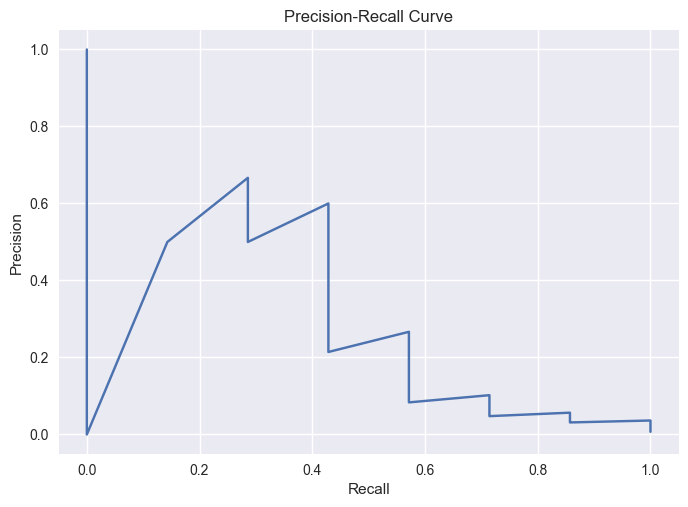

In [87]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds_tuned = precision_recall_curve(Y_val_dl, y_probs_tuned) 
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

In [88]:
# x_test_cnn_tuned = X_norm_test.reshape(X_norm_test.shape[0], X_norm_test.shape[1], 1)
y_pred_test_tuned = conv_tuned.predict(x_test_cnn)
y_pred_results_tuned = (y_pred_test_tuned > 0.5).astype(int) 
print(confusion_matrix(Y_test_labels, y_pred_results_tuned))
print(classification_report(Y_test_labels, y_pred_results_tuned))

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
[[564   1]
 [  2   3]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       565
           1       0.75      0.60      0.67         5

    accuracy                           0.99       570
   macro avg       0.87      0.80      0.83       570
weighted avg       0.99      0.99      0.99       570



In [89]:
conv.save('Exoplanet.best.keras')